In [1]:
from IPython.core.display import HTML

HTML("""
<style>
/* === 1. Caricamento font personalizzato (TikTokSans) === */
@font-face {
  font-family: 'TikTokSans';
  src: url('TikTokSans-VariableFont_opsz,slnt,wdth,wght.ttf') format('truetype');
}

/* === 2. Stile base della presentazione === */
.reveal {
  background-color: #ffffff !important;       /* Sfondo bianco */
  color: #121212 !important;                  /* Testo grigio scuro quasi nero */
  font-family: 'TikTokSans', sans-serif !important; /* Font personalizzato */
  font-size: 16px !important;                 /* Dimensione base leggermente ridotta */
}

/* === 3. Titoli con colore verde Spotify === */
.reveal h1 {
  font-size: 2em !important;
  color: #1DB954 !important;
}

.reveal h2 {
  font-size: 1.6em !important;
  color: #1DB954 !important;
}

.reveal h3 {
  font-size: 1.3em !important;
  color: #1DB954 !important;
}

/* === 4. Testi e liste più compatti === */
.reveal p,
.reveal li {
  font-size: 0.95em !important;
  color: #121212 !important;
}

/* === 5. Stile dei link === */
.reveal a {
  color: #1DB954 !important;
  text-decoration: underline;
}

/* === 6. Stile dei widget (etichette, pulsanti, selettori, ecc.) === */
.widget-label,
.widget-inline-hbox label,
.widget-readout,
.widget-radio-box label,
.widget-dropdown,
.widget-text,
.widget-button,
.widget-select,
.widget-toggle-button {
  font-family: 'TikTokSans', sans-serif !important;
  font-size: 14px !important;
}

/* Radio button e relative etichette */
.widget-radio-box label {
  font-weight: normal;
  padding-left: 6px;
}

/* Etichette di intestazione dei widget */
.widget-label > label {
  font-weight: bold;
}

/* Input generici (selettori, pulsanti, campi testo) */
select, input, button {
  font-family: 'TikTokSans', sans-serif !important;
}

/* === 7. Output del notebook === */

/* Rimuove bordo e sfondo dagli output */
div.output_area {
  border: none !important;
  box-shadow: none !important;
  background: transparent !important;
  padding: 0 !important;
  margin: 0 !important;
}

/* Figure in output (es. matplotlib) senza padding né bordo */
div.output_png {
  border: none !important;
  box-shadow: none !important;
  background-color: transparent !important;
  padding: 0 !important;
  margin: 0 auto !important;
  display: block;
}

/* Altri tipi di output (es. testo, HTML) */
.output_subarea {
  border: none !important;
  background: transparent !important;
  padding: 0 !important;
  margin: 0 !important;
  box-shadow: none !important;
}
</style>
""")

Francesco Sabot - 167339<br>
Università degli Studi di Udine - A.A. 2024/2025

# Analisi sui dati di ascolto<br>di un utente di Spotify

## Perché analizzare la cronologia di Spotify?
- L'interesse per tutto il mondo musicale
- Per capire come funziona il famoso Spotify Wrapped
- Per analizzare i comportamenti dell'utente

## Il dataset:
- il dataset è stato ricavato dalla sezione privacy di Spotify che permette a qualsiasi utente (premium e non) di scaricare la propria cronologia completa in più file json;
- i file json sono stati uniti da uno script python esterno. Il file generato è stato poi trasformato in seguito in un dataframe.

## Dati rilevanti:
- data e ora dell'ascolto
- tempo di ascolto in millisecondi
- paese di ascolto
- nome della traccia
- nome dell'artista
- nome dell'album
- motivo dell'inzio della canzone
- motivo della fine della canzone

## Domande
1. Cosa c'è dietro la creazione di Spotify Wrapped?
2. In che fascia oraria l'utente ascolta maggiormente musica?
3. Quali sono le ragioni principali per cui un brano finisce o inizia?
4. In quanto tempo l'utente salta un brano?
5. Dove sono stati effettuati gli ascolti da parte dell'utente?

In [2]:
# === Importazione librerie necessarie ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, widgets, Layout, HBox, VBox, Output
from datetime import datetime
import matplotlib.font_manager as fm
from matplotlib import ticker
import geopandas as gpd
import pycountry
import plotly.express as px
import plotly.io as pio
from IPython.display import clear_output, display
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

# === 1. Caricamento del font personalizzato TikTokSans ===
font_path = "TikTokSans-VariableFont_opsz,slnt,wdth,wght.ttf"
tik_tok_font = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = tik_tok_font.get_name()  # Applica globalmente il font a matplotlib

# === 2. Caricamento del file JSON con la cronologia di Spotify ===
file_path = './Spotify_Extended_Streaming_History_Merged.json'
df = pd.read_json(file_path)

# === 3. Modellazione dei dati ===

# Conversione della colonna timestamp in datetime
df['ts'] = pd.to_datetime(df['ts'], errors='coerce')

# Rimozione del fuso orario per standardizzare i dati
df['ts'] = df['ts'].dt.tz_localize(None)

# Calcolo dei minuti ascoltati da millisecondi
df['minutes_played'] = df['ms_played'] / 60000

# Estrazione dell'ora del giorno per analisi temporale
df['hour'] = df['ts'].dt.hour

# Valore massimo di ascolto tra i brani "skippati"
max_ms_played = int(df[df['skipped'] == True]['ms_played'].max())

# Raccolta degli anni presenti nel dataset
anni_disponibili = sorted(df['ts'].dt.year.unique().astype(str))

# Opzioni per selezione dinamica in widget (inclusa voce "Personalizzato")
anni_opzioni = anni_disponibili + ['Personalizzato']

# Estremi temporali del dataset
min_date = df['ts'].min().date()
max_date = df['ts'].max().date()

# === 4. Pre-elaborazione dati per Grafico 4: Analisi dei brani skippati ===

# Filtra solo le tracce saltate e le ordina per tempo
df_skipped = df[df['skipped'] == True].copy().sort_values(by='ts')

# Calcolo della durata media di ascolto per i brani skippati
media_skip = df_skipped['ms_played'].mean()

# Conteggi di skip in base a soglie temporali
skip_under_1s = (df_skipped['ms_played'] < 1000).sum()
skip_under_500ms = (df_skipped['ms_played'] < 500).sum()
skip_under_100ms = (df_skipped['ms_played'] < 100).sum()

# Impostazioni per asse Y nei grafici
default_y_limit = 30000
max_y_limit = int(df_skipped['ms_played'].max() + 10000)

# === 5. Impostazione renderer di default per Plotly (per Jupyter Notebook) ===
pio.renderers.default = "iframe"  # Usa iframe per visualizzazione isolata dei grafici

## 1. Cosa c'è dietro alla creazione di Spotify Wrapped?

In [3]:
# === Widget setup (semplificato) ===

anni_opzioni = ['2019', '2020', '2021', '2022', '2023', 'Personalizzato']
min_date = pd.to_datetime(df['ts'].min())
max_date = pd.to_datetime(df['ts'].max())

# Selezione dell'anno (o personalizzato)
annata_widget = widgets.Dropdown(
    options=anni_opzioni,
    value='Personalizzato',
    description='Anno',
    layout=Layout(width='250px')
)

# Selezione intervallo personalizzato
start_widget = widgets.DatePicker(
    description='Inizio',
    value=min_date,
    layout=Layout(width='200px')
)

end_widget = widgets.DatePicker(
    description='Fine',
    value=max_date,
    layout=Layout(width='200px')
)

# Numero di elementi Top N
topn_widget = widgets.IntSlider(
    value=10, min=5, max=25, step=1,
    description='Top N',
    layout=Layout(width='250px')
)

# Output grafico
output1 = Output()

# === Funzione di plotting (solo Artisti, solo Minuti) ===

def top_artisti_minuti(*args):
    with output1:
        output1.clear_output(wait=True)

        annata = annata_widget.value
        start_date = start_widget.value
        end_date = end_widget.value
        top_n = topn_widget.value

        # Intervallo date da anno o personalizzato
        if annata != 'Personalizzato':
            start_date = pd.to_datetime(f'{annata}-01-01')
            end_date = pd.to_datetime(f'{annata}-12-31')

        # Campo fisso: Artisti
        campo = 'master_metadata_track_name'

        # Filtro dati
        filtered = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]

        # Aggregazione: Minuti ascoltati
        agg = filtered.groupby(campo)['minutes_played'].sum()
        label_x = 'Minuti ascoltati'

        # Top N
        top = agg.sort_values(ascending=False).head(top_n).reset_index()
        top.columns = [campo, 'valore']

        # Palette (scala di verde)
        norm = plt.Normalize(top['valore'].min(), top['valore'].max())
        colors = [tuple(c) for c in plt.cm.Greens(norm(top['valore']))]

        # Grafico
        fig, ax = plt.subplots(figsize=(12, 6))
        FigureCanvas(fig)
        sns.set(style="whitegrid")

        # Barra con colore per artista
        sns.barplot(
            x='valore',
            y=campo,
            hue=campo,        # colore distinto per ogni artista
            data=top,
            palette=colors,
            legend=False,
            ax=ax
        )

        # Titoli e assi
        ax.set_title(
            f'Top {top_n} artisti per minuti ascoltati\n({start_date.date()} - {end_date.date()})',
            fontsize=22,
            pad=25,
            fontproperties=tik_tok_font
        )
        ax.set_xlabel(label_x, fontsize=16, labelpad=15, fontproperties=tik_tok_font)
        ax.set_ylabel('Traccia', fontsize=16, labelpad=15, fontproperties=tik_tok_font)

        # Valori numerici
        for i, row in top.iterrows():
            ax.text(
                row.valore + top['valore'].max() * 0.01, i,
                f"{row.valore:.0f}",
                va='center',
                fontsize=12,
                fontproperties=tik_tok_font
            )

        # Font etichette
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tik_tok_font)
            label.set_fontsize(12)

        sns.despine()
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

# === Controllo visibilità DatePicker ===
def update_visibility(*args):
    visible = annata_widget.value == 'Personalizzato'
    start_widget.layout.display = 'inline-flex' if visible else 'none'
    end_widget.layout.display = 'inline-flex' if visible else 'none'

annata_widget.observe(update_visibility, names='value')

# === Collega eventi ai widget ===
for w in [annata_widget, start_widget, end_widget, topn_widget]:
    w.observe(top_artisti_minuti, names='value')

# === Layout ===
anno_row = HBox([annata_widget, start_widget, end_widget],
                layout=Layout(align_items='center', gap='10px'))

controls = VBox([
    anno_row,
    topn_widget
])

# === Avvio interfaccia ===
display(controls, output1)
update_visibility()
top_artisti_minuti()


Output()

In [4]:
# === Widget setup (semplificato) ===

anni_opzioni = ['2019', '2020', '2021', '2022', '2023', 'Personalizzato']
min_date = pd.to_datetime(df['ts'].min())
max_date = pd.to_datetime(df['ts'].max())

# Selezione dell'anno (o personalizzato)
annata_widget = widgets.Dropdown(
    options=anni_opzioni,
    value='Personalizzato',
    description='Anno',
    layout=Layout(width='250px')
)

# Selezione intervallo personalizzato
start_widget = widgets.DatePicker(
    description='Inizio',
    value=min_date,
    layout=Layout(width='200px')
)

end_widget = widgets.DatePicker(
    description='Fine',
    value=max_date,
    layout=Layout(width='200px')
)

# Numero di elementi Top N
topn_widget = widgets.IntSlider(
    value=10, min=5, max=25, step=1,
    description='Top N',
    layout=Layout(width='250px')
)

# Output grafico
output1 = Output()

# === Funzione di plotting (solo Artisti, solo Minuti) ===

def top_artisti_minuti(*args):
    with output1:
        output1.clear_output(wait=True)

        annata = annata_widget.value
        start_date = start_widget.value
        end_date = end_widget.value
        top_n = topn_widget.value

        # Intervallo date da anno o personalizzato
        if annata != 'Personalizzato':
            start_date = pd.to_datetime(f'{annata}-01-01')
            end_date = pd.to_datetime(f'{annata}-12-31')

        # Campo fisso: Artisti
        campo = 'master_metadata_album_artist_name'

        # Filtro dati
        filtered = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]

        # Aggregazione: Minuti ascoltati
        agg = filtered.groupby(campo)['minutes_played'].sum()
        label_x = 'Minuti ascoltati'

        # Top N
        top = agg.sort_values(ascending=False).head(top_n).reset_index()
        top.columns = [campo, 'valore']

        # Palette (scala di verde)
        norm = plt.Normalize(top['valore'].min(), top['valore'].max())
        colors = [tuple(c) for c in plt.cm.Greens(norm(top['valore']))]

        # Grafico
        fig, ax = plt.subplots(figsize=(12, 6))
        FigureCanvas(fig)
        sns.set(style="whitegrid")

        # Barra con colore per artista
        sns.barplot(
            x='valore',
            y=campo,
            hue=campo,        # colore distinto per ogni artista
            data=top,
            palette=colors,
            legend=False,
            ax=ax
        )

        # Titoli e assi
        ax.set_title(
            f'Top {top_n} artisti per minuti ascoltati\n({start_date.date()} - {end_date.date()})',
            fontsize=22,
            pad=25,
            fontproperties=tik_tok_font
        )
        ax.set_xlabel(label_x, fontsize=16, labelpad=15, fontproperties=tik_tok_font)
        ax.set_ylabel('Artista', fontsize=16, labelpad=15, fontproperties=tik_tok_font)

        # Valori numerici
        for i, row in top.iterrows():
            ax.text(
                row.valore + top['valore'].max() * 0.01, i,
                f"{row.valore:.0f}",
                va='center',
                fontsize=12,
                fontproperties=tik_tok_font
            )

        # Font etichette
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tik_tok_font)
            label.set_fontsize(12)

        sns.despine()
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

# === Controllo visibilità DatePicker ===
def update_visibility(*args):
    visible = annata_widget.value == 'Personalizzato'
    start_widget.layout.display = 'inline-flex' if visible else 'none'
    end_widget.layout.display = 'inline-flex' if visible else 'none'

annata_widget.observe(update_visibility, names='value')

# === Collega eventi ai widget ===
for w in [annata_widget, start_widget, end_widget, topn_widget]:
    w.observe(top_artisti_minuti, names='value')

# === Layout ===
anno_row = HBox([annata_widget, start_widget, end_widget],
                layout=Layout(align_items='center', gap='10px'))

controls = VBox([
    anno_row,
    topn_widget
])

# === Avvio interfaccia ===
display(controls, output1)
update_visibility()
top_artisti_minuti()

Output()

In [5]:
# === Widget setup (semplificato) ===

anni_opzioni = ['2019', '2020', '2021', '2022', '2023', 'Personalizzato']
min_date = pd.to_datetime(df['ts'].min())
max_date = pd.to_datetime(df['ts'].max())

# Selezione dell'anno (o personalizzato)
annata_widget = widgets.Dropdown(
    options=anni_opzioni,
    value='Personalizzato',
    description='Anno',
    layout=Layout(width='250px')
)

# Selezione intervallo personalizzato
start_widget = widgets.DatePicker(
    description='Inizio',
    value=min_date,
    layout=Layout(width='200px')
)

end_widget = widgets.DatePicker(
    description='Fine',
    value=max_date,
    layout=Layout(width='200px')
)

# Numero di elementi Top N
topn_widget = widgets.IntSlider(
    value=10, min=5, max=25, step=1,
    description='Top N',
    layout=Layout(width='250px')
)

# Output grafico
output1 = Output()

# === Funzione di plotting (solo Artisti, solo Minuti) ===

def top_artisti_minuti(*args):
    with output1:
        output1.clear_output(wait=True)

        annata = annata_widget.value
        start_date = start_widget.value
        end_date = end_widget.value
        top_n = topn_widget.value

        # Intervallo date da anno o personalizzato
        if annata != 'Personalizzato':
            start_date = pd.to_datetime(f'{annata}-01-01')
            end_date = pd.to_datetime(f'{annata}-12-31')

        # Campo fisso: Artisti
        campo = 'master_metadata_album_album_name'

        # Filtro dati
        filtered = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]

        # Aggregazione: Minuti ascoltati
        agg = filtered.groupby(campo)['minutes_played'].sum()
        label_x = 'Minuti ascoltati'

        # Top N
        top = agg.sort_values(ascending=False).head(top_n).reset_index()
        top.columns = [campo, 'valore']

        # Palette (scala di verde)
        norm = plt.Normalize(top['valore'].min(), top['valore'].max())
        colors = [tuple(c) for c in plt.cm.Greens(norm(top['valore']))]

        # Grafico
        fig, ax = plt.subplots(figsize=(12, 6))
        FigureCanvas(fig)
        sns.set(style="whitegrid")

        # Barra con colore per artista
        sns.barplot(
            x='valore',
            y=campo,
            hue=campo,        # colore distinto per ogni artista
            data=top,
            palette=colors,
            legend=False,
            ax=ax
        )

        # Titoli e assi
        ax.set_title(
            f'Top {top_n} artisti per minuti ascoltati\n({start_date.date()} - {end_date.date()})',
            fontsize=22,
            pad=25,
            fontproperties=tik_tok_font
        )
        ax.set_xlabel(label_x, fontsize=16, labelpad=15, fontproperties=tik_tok_font)
        ax.set_ylabel('Album', fontsize=16, labelpad=15, fontproperties=tik_tok_font)

        # Valori numerici
        for i, row in top.iterrows():
            ax.text(
                row.valore + top['valore'].max() * 0.01, i,
                f"{row.valore:.0f}",
                va='center',
                fontsize=12,
                fontproperties=tik_tok_font
            )

        # Font etichette
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontproperties(tik_tok_font)
            label.set_fontsize(12)

        sns.despine()
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

# === Controllo visibilità DatePicker ===
def update_visibility(*args):
    visible = annata_widget.value == 'Personalizzato'
    start_widget.layout.display = 'inline-flex' if visible else 'none'
    end_widget.layout.display = 'inline-flex' if visible else 'none'

annata_widget.observe(update_visibility, names='value')

# === Collega eventi ai widget ===
for w in [annata_widget, start_widget, end_widget, topn_widget]:
    w.observe(top_artisti_minuti, names='value')

# === Layout ===
anno_row = HBox([annata_widget, start_widget, end_widget],
                layout=Layout(align_items='center', gap='10px'))

controls = VBox([
    anno_row,
    topn_widget
])

# === Avvio interfaccia ===
display(controls, output1)
update_visibility()
top_artisti_minuti()


Output()

## 2. In che fascia oraria l'utente ascolta maggiormente musica?

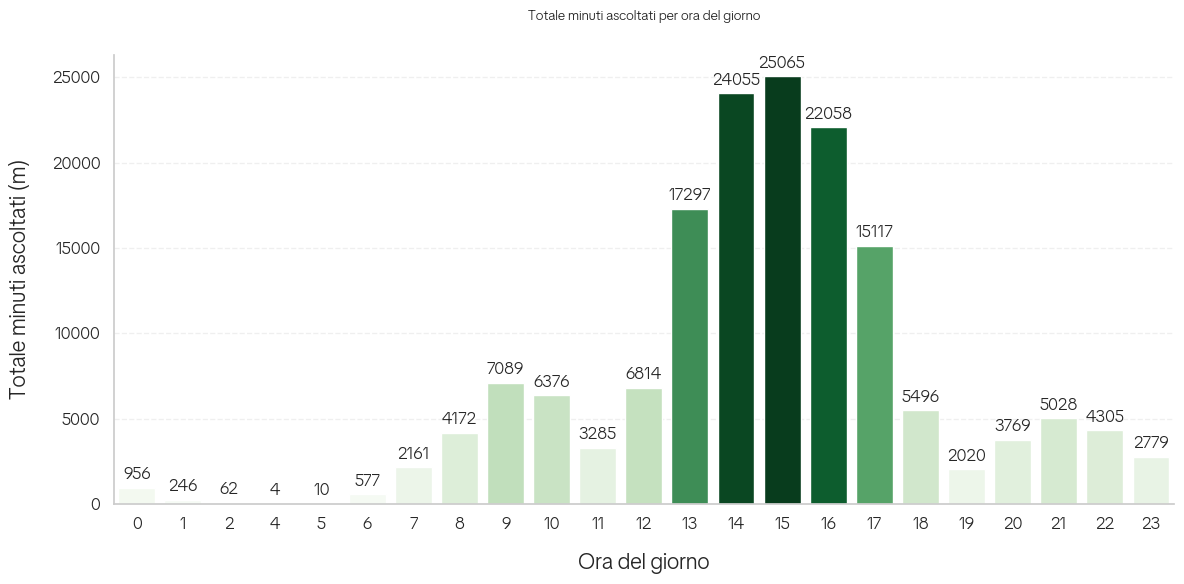

In [6]:
def grafico_orario():
    # === 1. Aggregazione dei dati per ora ===
    # Raggruppa i dati per ora del giorno (0–23) e somma i minuti ascoltati
    hourly_sum = df.groupby('hour')['minutes_played'].sum().reset_index()

    # === 2. Generazione della palette dinamica in scala di verde ===
    norm = plt.Normalize(hourly_sum['minutes_played'].min(), hourly_sum['minutes_played'].max())
    colors = [tuple(c) for c in plt.cm.Greens(norm(hourly_sum['minutes_played']))]

    # === 3. Setup del grafico ===
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.set(style="whitegrid")  # Tema con sfondo bianco e griglia chiara

    # === 4. Creazione del grafico a barre orarie ===
    sns.barplot(
        x='hour',
        y='minutes_played',
        hue='hour',                  # Hue usato per assegnare colori distinti a ogni ora
        data=hourly_sum,
        palette=colors,
        legend=False,               # Nessuna legenda necessaria
        ax=ax
    )

    # === 5. Etichette sopra ogni barra ===
    for i, row in hourly_sum.iterrows():
        ax.text(
            i,
            row.minutes_played + max(hourly_sum['minutes_played']) * 0.02,
            f"{row.minutes_played:.0f}",
            ha='center',
            fontsize=12,
            fontproperties=tik_tok_font
        )

    # === 6. Titoli e assi con font personalizzato ===
    ax.set_title(
        'Totale minuti ascoltati per ora del giorno',
        fontsize=22,
        pad=25,
        fontproperties=tik_tok_font
    )
    ax.set_xlabel('Ora del giorno', fontsize=16, labelpad=15, fontproperties=tik_tok_font)
    ax.set_ylabel('Totale minuti ascoltati (m)', fontsize=16, labelpad=15, fontproperties=tik_tok_font)

    # === 7. Font personalizzato per le etichette degli assi ===
    for label in ax.get_xticklabels():
        label.set_fontproperties(tik_tok_font)
        label.set_fontsize(12)
    for label in ax.get_yticklabels():
        label.set_fontproperties(tik_tok_font)
        label.set_fontsize(12)

    # === 8. Pulizia del grafico ===
    sns.despine()                               # Rimuove bordi superflui
    ax.grid(axis='y', linestyle='--', alpha=0.3)  # Griglia orizzontale leggera
    plt.tight_layout()
    plt.show()

# === Esecuzione della funzione ===
grafico_orario()

## 3. Quali sono le ragioni principali per cui un brano finisce o inizia?

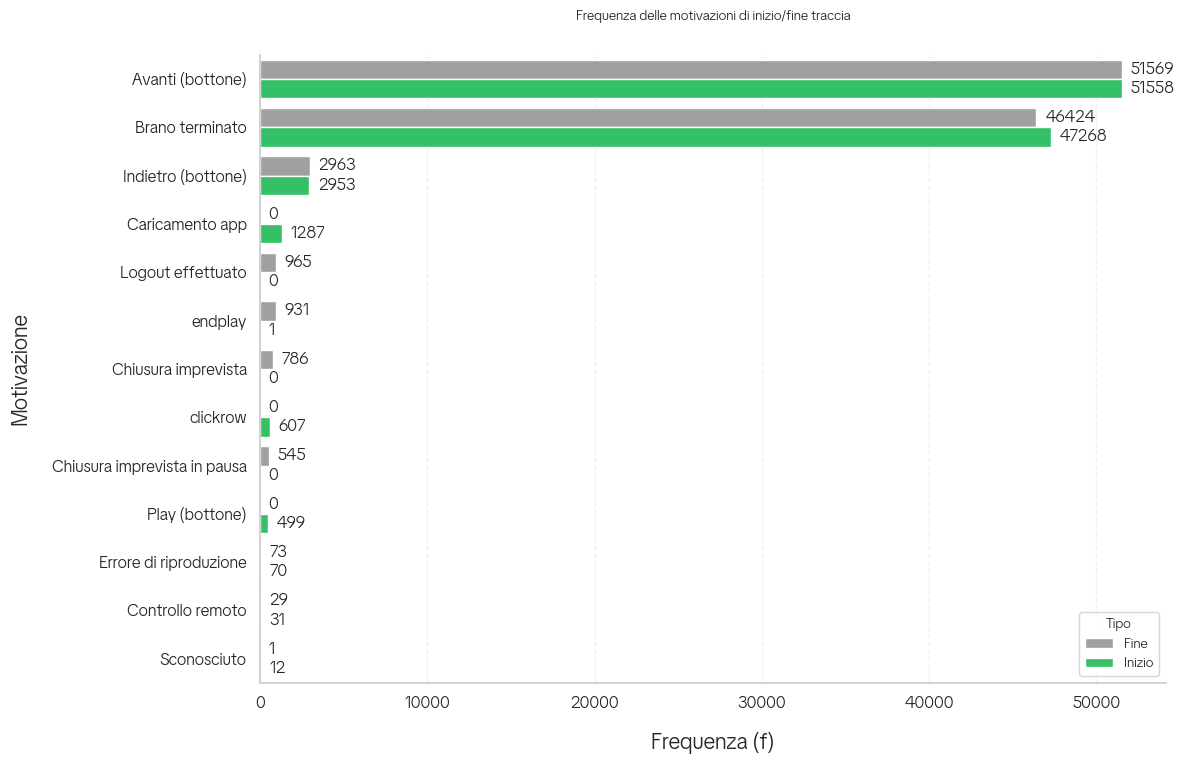

In [7]:
event_translation = {
    "fwdbtn": "Avanti (bottone)",
    "trackdone": "Brano terminato",
    "backbtn": "Indietro (bottone)",
    "appload": "Caricamento app",
    "logout": "Logout effettuato",
    "gndplay": "Riproduzione automatica",
    "unexpected-exit": "Chiusura imprevista",
    "dickrow": "Selezione da elenco",
    "unexpected-exit-while-paused": "Chiusura imprevista in pausa",
    "playbtn": "Play (bottone)",
    "trackerror": "Errore di riproduzione",
    "remote": "Controllo remoto",
    "unknown": "Sconosciuto"
}

tipo_translation = {
    "Start": "Inizio",
    "End": "Fine"
}

def motivo_inizio_fine():
    # === 1. Tipologie da confrontare: start e end ===
    tipo = ["Start", "End"]

    # === 2. Copia dell'intero DataFrame (nessun filtro temporale) ===
    filtered = df.copy()

    # --- correzione refuso tnknown -> unknown ---
    for col in ['reason_start', 'reason_end']:
        if col in filtered.columns:
            filtered[col] = filtered[col].replace('tnknown', 'unknown')

    # === 3. Recupero di tutte le motivazioni uniche presenti in entrambi i campi ===
    all_reasons = set(filtered['reason_start'].dropna().unique()) | set(filtered['reason_end'].dropna().unique())

    # === 4. Conteggio delle motivazioni di inizio ===
    start_counts = (
        filtered['reason_start']
        .value_counts()
        .reindex(all_reasons, fill_value=0)
        .reset_index()
    )
    start_counts.columns = ['reason', 'count']
    start_counts['type'] = 'Start'

    # === 5. Conteggio delle motivazioni di fine ===
    end_counts = (
        filtered['reason_end']
        .value_counts()
        .reindex(all_reasons, fill_value=0)
        .reset_index()
    )
    end_counts.columns = ['reason', 'count']
    end_counts['type'] = 'End'

    # === 6. Unione dei due DataFrame ===
    reason_data = pd.concat([start_counts, end_counts], ignore_index=True)

    # === 7. Ordinamento motivazioni per frequenza totale (start + end) ===
    total_counts = reason_data.groupby('reason')['count'].sum().sort_values(ascending=False)
    reason_order = total_counts.index.tolist()

    # Imposta ordine categorico per il grafico
    reason_data['reason'] = pd.Categorical(reason_data['reason'], categories=reason_order, ordered=True)
    reason_data = reason_data.sort_values(by='reason')

    # === 8. Imposta altezza dinamica in base al numero di motivazioni ===
    fig_height = max(6, len(reason_order) * 0.6)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    sns.set(style="whitegrid")

    # === 9. Definizione dei colori per Start e End ===
    palette = {
        'Start': '#1ed760',  # Verde Spotify
        'End': '#A0A0A0'     # Grigio neutro
    }

    # === 10. Grafico a barre raggruppate ===
    sns.barplot(
        x='count',
        y='reason',
        hue='type',
        data=reason_data,
        palette=palette,
        ax=ax
    )

    # === 11. Titolo e assi con font personalizzato ===
    ax.set_title(
        'Frequenza delle motivazioni di inizio/fine traccia',
        fontsize=22,
        pad=25,
        fontproperties=tik_tok_font
    )
    ax.set_xlabel('Frequenza (f)', fontsize=16, labelpad=15, fontproperties=tik_tok_font)
    ax.set_ylabel('Motivazione', fontsize=16, labelpad=15, fontproperties=tik_tok_font)

    # === 12: mappa le etichette Y in italiano ===
    cats = list(reason_data['reason'].cat.categories)
    mapped_labels = [event_translation.get(c, c) for c in cats]
    ax.set_yticks(range(len(cats)))        # fissa le posizioni dei tick
    ax.set_yticklabels(mapped_labels)      # assegna le etichette tradotte

    # === 13. Etichette numeriche su ogni barra ===
    max_count = max(reason_data['count'].max(), 1)  # Per posizionamento sicuro
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2
            label_text = f"{int(width)}" if width > 0 else "0"
            ax.text(
                width + max_count * 0.01 if width > 0 else max_count * 0.01,
                y,
                label_text,
                va='center',
                fontsize=12,
                fontproperties=tik_tok_font
            )

    # === 14. Font delle etichette assi ===
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(tik_tok_font)
        label.set_fontsize(12)

    # === 15. Legenda personalizzata ===
    handles, labels = ax.get_legend_handles_labels()
    mapped_labels = [tipo_translation.get(l, l) for l in labels]  # traduci Start/End
    ax.legend(
        handles,
        mapped_labels,
        title='Tipo',
        loc='lower right',
        prop=tik_tok_font,
        title_fontproperties=tik_tok_font
    )

    # === 16. Finitura grafico ===
    sns.despine()
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# === Esecuzione della funzione ===
motivo_inizio_fine()

## 4. In quanto tempo l'utente salta un brano?

In [31]:
# === Output area per il grafico ===
output2 = widgets.Output()

# === Funzione di disegno del grafico (boxplot per mese con Y al 90,5° percentile) ===
def draw_skip_vs_durata():
    with output2:
        clear_output(wait=True)

        # 1) Prepara i dati
        df_box = df_skipped.copy()
        df_box['ts'] = pd.to_datetime(df_box['ts'], errors='coerce')
        df_box = df_box.dropna(subset=['ts', 'ms_played'])
        df_box['month'] = df_box['ts'].dt.to_period('M').astype(str)

        # 2) Ordine cronologico dei mesi
        mesi_ordinati = sorted(df_box['month'].unique())

        # 3) Limite Y = 95° percentile (più leggibile, riduce outlier estremi)
        y_limit = df_box['ms_played'].quantile(0.905)

        # 4) Setup grafico
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.set(style="whitegrid")

        # 5) Boxplot per mese
        sns.boxplot(
            x='month',
            y='ms_played',
            data=df_box,
            order=mesi_ordinati,
            color='#1ed760',
            showfliers=False,   # coerente col taglio al 95°
            width=0.6,
            ax=ax
        )

        # 7) Limite Y statico
        ax.set_ylim(0, y_limit)

        # 8) Titolo e assi
        ax.set_title(
            'Distribuzione mensile delle durate degli ascolti skippati (boxplot, Y=90,5° pct)',
            fontsize=22,
            pad=25,
            fontproperties=tik_tok_font
        )
        ax.set_xlabel('Mese (YYYY-MM)', fontsize=16, labelpad=15, fontproperties=tik_tok_font)
        ax.set_ylabel('Millisecondi ascoltati (ms)', fontsize=16, labelpad=15, fontproperties=tik_tok_font)

        # 9) Tick labels
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')
            label.set_fontproperties(tik_tok_font)
            label.set_fontsize(11)
        for label in ax.get_yticklabels():
            label.set_fontproperties(tik_tok_font)
            label.set_fontsize(12)

        # 10) Stile finale
        sns.despine()
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

# === Mostra il grafico statico ===
draw_skip_vs_durata()
display(output2)

Output()

## 5. Dove sono stati effettuati gli ascolti da parte dell'utente?

In [9]:
# === 1. Funzione di conversione da codice ISO-2 a ISO-3 ===
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None  # Se il codice è invalido o mancante

# === 2. Funzione principale per generare la mappa ===
def mappa_interattiva_ascolti():
    # === 2.1 Aggrega i minuti ascoltati per paese ===
    stato_stats = (
        df.groupby('conn_country')['minutes_played']
        .sum()
        .reset_index()
    )

    # === 2.2 Conversione dei codici paese ISO-2 → ISO-3 ===
    stato_stats['iso_alpha_3'] = stato_stats['conn_country'].apply(iso2_to_iso3)

    # === 2.3 Nome esteso del paese (es. 'IT' → 'Italy') ===
    stato_stats['country_name'] = stato_stats['conn_country'].apply(
        lambda code: pycountry.countries.get(alpha_2=code).name if pycountry.countries.get(alpha_2=code) else code
    )

    # === 2.4 Rimozione dei record con codici non riconosciuti ===
    stato_stats = stato_stats.dropna(subset=['iso_alpha_3'])

    # === 2.5 Arrotondamento dei minuti a due decimali ===
    stato_stats['minutes_played'] = stato_stats['minutes_played'].round(2)

    # === 3. Creazione della mappa coropletica con Plotly ===
    fig = px.choropleth(
        stato_stats,
        locations='iso_alpha_3',           # Codici ISO-3 per posizionare i paesi
        color='minutes_played',            # Variabile da rappresentare con colore
        hover_name='country_name',         # Nome da mostrare al passaggio del mouse
        hover_data={
            'minutes_played': ':.2f',      # Mostra 2 decimali
            'iso_alpha_3': False           # Nasconde il codice ISO-3
        },
        color_continuous_scale='Greens',   # Scala colore in tonalità verdi
        labels={'minutes_played': 'Minuti ascoltati'},
        projection='natural earth'         # Proiezione geografica
    )

    # === 4. Personalizzazione della mappa ===
    fig.update_geos(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        fitbounds="locations"
    )

    # === 5. Layout estetico e barra colore ===
    fig.update_layout(
        title=None,
        font=dict(
            family="TikTok Sans 36pt",  # Nome del font (assicurati sia registrato)
            size=14,
            color="black"
        ),
        margin=dict(l=0, r=0, t=60, b=0),  # Margini grafico
        geo=dict(bgcolor='rgba(0,0,0,0)'),  # Sfondo trasparente
        coloraxis_colorbar=dict(
            x=-0.05,                    # Posizione orizzontale barra colore
            y=0.5,                      # Centrata verticalmente
            len=0.95,                   # Altezza barra
            title='Minuti ascoltati (m)',
            ticks='outside'
        )
    )

    # === 6. Visualizza la mappa ===
    fig.show()

# === Esecuzione della funzione ===
mappa_interattiva_ascolti()

## Conclusioni

Insights emersi:
- I brani, album e artisti preferiti sono stati individuati grazie al primo grafico;
- L'utente è solito ad ascoltare la musica maggiormente nelle ore pomeridiane;
- Molti ascolti vengono skippati entro il primo secondo, indicando comportamenti impulsivi o uso passivo;
- Le motivazioni di inizio/fine traccia più frequenti possono rivelare modalità di interazione con l'app;
- Gli ascolti si distribuiscono su diversi paesi, con alcune aree geografiche più attive.

Scalabilità del progetto:
- Il codice può essere facilmente esteso per includere altri tipi di metriche, nuove visualizzazioni o per essere integrato in una dashboard web interattiva (es. con Jupyter-Flex).

## Grazie per l'attenzione